In [2]:
pip install TruthTorchLM

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 9.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import TruthTorchLM as ttlm
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
os.environ["OPENAI_API_KEY"] = ''
import torch

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


#Initialize and download models

In [4]:
model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3-8B-Instruct", torch_dtype=torch.bfloat16).to('cuda:0')
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B-Instruct", use_fast=False)

api_model = "gpt-4o-mini"


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

In [5]:
model_judge = ttlm.evaluators.ModelJudge('gpt-4o-mini')

# Initialize truth methods

In [6]:
import os
import shutil
from pathlib import Path
from transformers import DebertaForSequenceClassification, DebertaTokenizer

# clear Hugging Face cache to force fresh download
hf_cache_dir = Path.home() / ".cache" / "huggingface"
if hf_cache_dir.exists():
    print(f"Clearing Hugging Face cache at: {hf_cache_dir}")
    shutil.rmtree(hf_cache_dir)

#define different truth methodsfound under src/TruthTorchLM/truth_methods
lars = ttlm.truth_methods.LARS(device='cuda')#https://arxiv.org/pdf/2406.11278
verb_confidence = ttlm.truth_methods.VerbalizedConfidence()
sar = ttlm.truth_methods.SAR(similarity_model_device='cuda')
multillm = ttlm.truth_methods.MultiLLMCollab()

# LLaMA (all methods)
truth_methods = [lars, verb_confidence, sar, multillm]
# GPT-4o-mini (black-box only)
truth_methods_api = [verb_confidence, multillm]

Clearing Hugging Face cache at: /root/.cache/huggingface


config.json:   0%|          | 0.00/985 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Collaboration mode: coop_self


# Calibration of the truth methods

## 1. LLama-3-8B

### 1.1. TriviaQA

In [5]:
model_judge = ttlm.evaluators.ModelJudge('gpt-4o-mini')
for truth_method in truth_methods:
    truth_method.set_normalizer(ttlm.normalizers.IsotonicRegression())
calibration_results_1 = ttlm.calibrate_truth_method(dataset = 'trivia_qa', model = model, truth_methods = truth_methods, tokenizer = tokenizer, correctness_evaluator = model_judge,
    size_of_data = 200,  return_method_details = True, seed = 0, max_new_tokens = 64, pad_token_id=tokenizer.eos_token_id)

Loading dataset from Huggingface Datasets, split: train fraction of data: 200


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

rc.nocontext/train-00000-of-00001.parque(…):   0%|          | 0.00/55.4M [00:00<?, ?B/s]

rc.nocontext/validation-00000-of-00001.p(…):   0%|          | 0.00/7.34M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/17210 [00:00<?, ? examples/s]

100%|██████████| 200/200 [00:00<00:00, 1280.89it/s]


Running Model over dataset with 200 examples


  0%|          | 0/200 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|██████████| 200/200 [1:05:38<00:00, 19.69s/it]

Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}
Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}
Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}
Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}


Save and download the calibration resluts

In [6]:
import pickle
from google.colab import files

with open('calibration_results_1.pkl', 'wb') as f:
    pickle.dump(calibration_results_1, f)

files.download('calibration_results_1.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 1.2. GSM8K

In [7]:
for truth_method in truth_methods:
    truth_method.set_normalizer(ttlm.normalizers.IsotonicRegression())
calibration_results2 = ttlm.calibrate_truth_method(dataset = 'gsm8k', model = model, truth_methods = truth_methods, tokenizer = tokenizer, correctness_evaluator = model_judge,
    size_of_data = 200,  return_method_details = True, seed = 0, max_new_tokens = 64, pad_token_id=tokenizer.eos_token_id)

Loading dataset from Huggingface Datasets, split: train fraction of data: 200


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

100%|██████████| 200/200 [00:00<00:00, 3154.38it/s]


Running Model over dataset with 200 examples


100%|██████████| 200/200 [1:45:09<00:00, 31.55s/it]

Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}
Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}
Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}
Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}


Save and download the calibration results

In [8]:
import pickle
from google.colab import files

with open('calibration_results_2.pkl', 'wb') as f:
    pickle.dump(calibration_results2, f)

files.download('calibration_results_2.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. GPT-4o-mini

### Temporary patch:
This patch will intercept the generate_api_or_hf_local function, check if the 'messages' key is missing from its output, and manually inject it using the arguments that were passed to it.

### Reason:
On testing with an api model a KeyError: 'messages' kept appearing and was caused by an internal bug in the TruthTorchLM library when working with API-based models (like gpt-4o-mini).

NOTE: *Patch code generated by Gemini*

In [7]:
import TruthTorchLM.utils.eval_utils as eu

# save the original function to a hidden attribute so we don't accidentally patch it twice
if not hasattr(eu, '_original_generate_api_or_hf_local'):
    eu._original_generate_api_or_hf_local = eu.generate_api_or_hf_local

def patched_generate_api_or_hf_local(*args, **kwargs):
    # call the original function to do the actual generation
    result = eu._original_generate_api_or_hf_local(*args, **kwargs)

    # if the result is missing the 'messages' key, inject it from kwargs
    if isinstance(result, dict) and 'messages' not in result:
        if 'messages' in kwargs:
            result['messages'] = kwargs['messages']

    return result

# apply the patch by replacing the function reference in the module
eu.generate_api_or_hf_local = patched_generate_api_or_hf_local
print("Monkey patch applied successfully! The 'messages' key will now be retained.")

Monkey patch applied successfully! The 'messages' key will now be retained.


### 2.1. TriviaQA

In [8]:
for truth_method in truth_methods_api:
    truth_method.set_normalizer(ttlm.normalizers.IsotonicRegression())

calibration_results_3 = ttlm.calibrate_truth_method(
    dataset='trivia_qa',
    model= api_model,
    truth_methods=truth_methods_api,
    correctness_evaluator=model_judge,
    size_of_data=200,
    return_method_details=True,
    seed=0,
    previous_context=[{"role": "system", "content": ttlm.templates.DEFAULT_SYSTEM_BENCHMARK_PROMPT}],
    user_prompt=ttlm.templates.DEFAULT_USER_PROMPT,
    split='train'
)

Loading dataset from Huggingface Datasets, split: train fraction of data: 200


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

rc.nocontext/train-00000-of-00001.parque(…):   0%|          | 0.00/55.4M [00:00<?, ?B/s]

rc.nocontext/validation-00000-of-00001.p(…):   0%|          | 0.00/7.34M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/17210 [00:00<?, ? examples/s]

100%|██████████| 200/200 [00:00<00:00, 1300.88it/s]


Running Model over dataset with 200 examples


100%|██████████| 200/200 [1:24:12<00:00, 25.26s/it]

Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}
Calibrated with the following parameters: {'increasing': True, 'out_of_bounds': 'clip', 'y_max': 1.0, 'y_min': 0.0}


Save and download calibration results

In [ ]:
import pickle
from google.colab import files

with open('calibration_results_3.pkl', 'wb') as f:
    pickle.dump(calibration_results_3, f)

files.download('calibration_results_3.pkl')

### 2.2. GSM8K

In [ ]:
for truth_method in truth_methods_api:
    truth_method.set_normalizer(ttlm.normalizers.IsotonicRegression())

calibration_results_4 = ttlm.calibrate_truth_method(
    dataset='gsm8k',
    model= api_model,
    truth_methods=truth_methods_api,
    correctness_evaluator=model_judge,
    size_of_data=200,
    return_method_details=True,
    seed=0,
    previous_context=[{"role": "system", "content": ttlm.templates.DEFAULT_SYSTEM_BENCHMARK_PROMPT}],
    user_prompt=ttlm.templates.DEFAULT_USER_PROMPT,
    split='train'
)

Save and download calibration results

In [ ]:
import pickle
from google.colab import files

with open('calibration_results_4.pkl', 'wb') as f:
    pickle.dump(calibration_results_4, f)

files.download('calibration_results_4.pkl')

# Evaluation process

## 1. Llama-3-8B

### 1.1 TriviaQA

In [7]:
results_1 = ttlm.evaluate_truth_method(
    dataset='trivia_qa',
    model=model,
    truth_methods=truth_methods,
    eval_metrics=['auroc', 'prr'],
    tokenizer=tokenizer,
    size_of_data=200,
    correctness_evaluator=model_judge,
    return_method_details=True,
    batch_generation=True,
    max_new_tokens=64,
    do_sample=True,
    seed=42,
    pad_token_id=tokenizer.eos_token_id
)

Loading dataset from Huggingface Datasets, split: test fraction of data: 200


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

rc.nocontext/train-00000-of-00001.parque(…):   0%|          | 0.00/55.4M [00:00<?, ?B/s]

rc.nocontext/validation-00000-of-00001.p(…):   0%|          | 0.00/7.34M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/17944 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/17210 [00:00<?, ? examples/s]

100%|██████████| 200/200 [00:00<00:00, 2109.87it/s]


Running Model over dataset with 200 examples


  0%|          | 0/200 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|██████████| 200/200 [1:11:28<00:00, 21.44s/it]


Display the scores

In [8]:
for i in range(len(results_1['eval_list'])):
    print(results_1['output_dict']['truth_methods'][i],results_1['eval_list'][i])

LARS {'auroc': np.float64(0.8473825503355705), 'prr': np.float64(0.7538680412393367)}
VerbalizedConfidence {'auroc': np.float64(0.7387919463087249), 'prr': np.float64(0.4910365258235761)}
SAR {'auroc': np.float64(0.7845637583892617), 'prr': np.float64(0.6464647287136506)}
MultiLLMCollab {'auroc': np.float64(0.6622818791946309), 'prr': np.float64(0.3981893033211887)}


Save and download the evaluation scores

In [10]:
import pandas as pd
from google.colab import files

rows = []
for i in range(len(results_1['eval_list'])):
    method = results_1['output_dict']['truth_methods'][i]
    metrics = results_1['eval_list'][i]

    row = {'method': str(method)}

    if isinstance(metrics, dict):
        row.update(metrics)
    else:
        row['score'] = metrics

    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv('evaluation_metrics.csv', index=False)
print("Evaluation Metrics:")
print(metrics_df)

if 'method_details' in results_1['output_dict']:
    details_rows = []

    for i, method in enumerate(results_1['output_dict']['truth_methods']):
        method_detail = results_1['output_dict']['method_details'][i]

        for j, example in enumerate(method_detail):
            row = {'method': str(method), 'example_index': j}

            if isinstance(example, dict):
                row.update(example)
            else:
                row['value'] = example

            details_rows.append(row)

    details_df = pd.DataFrame(details_rows)
    details_df.to_csv('evaluation_details.csv', index=False)
    print("\nPer-Example Details:")
    print(details_df.head(10))

print("\nDownloading files...")
files.download('evaluation_metrics.csv')

if 'method_details' in results_1['output_dict']:
    files.download('evaluation_details.csv')

print("Done!")

Evaluation Metrics:
                 method     auroc       prr
0                  LARS  0.847383  0.753868
1  VerbalizedConfidence  0.738792  0.491037
2                   SAR  0.784564  0.646465
3        MultiLLMCollab  0.662282  0.398189



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


### 1.2 GSM8K

In [11]:
results_2 = ttlm.evaluate_truth_method(
    dataset='gsm8k',
    model=model,
    truth_methods=truth_methods,
    eval_metrics=['auroc', 'prr'],
    tokenizer=tokenizer,
    size_of_data=200,
    correctness_evaluator=model_judge,
    return_method_details=True,
    batch_generation=True,
    max_new_tokens=64,
    do_sample=True,
    seed=42,
    pad_token_id=tokenizer.eos_token_id
)

Loading dataset from Huggingface Datasets, split: test fraction of data: 200


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

100%|██████████| 200/200 [00:00<00:00, 3286.27it/s]


Running Model over dataset with 200 examples


100%|██████████| 200/200 [1:52:11<00:00, 33.66s/it]


Display the scores

In [12]:
for i in range(len(results_2['eval_list'])):
    print(results_2['output_dict']['truth_methods'][i],results_2['eval_list'][i])

LARS {'auroc': np.float64(0.8727396021699819), 'prr': np.float64(0.7802287040159395)}
VerbalizedConfidence {'auroc': np.float64(0.5457165461121157), 'prr': np.float64(0.22498396200865092)}
SAR {'auroc': np.float64(0.8011980108499095), 'prr': np.float64(0.6659257001672702)}
MultiLLMCollab {'auroc': np.float64(0.6903820072332729), 'prr': np.float64(0.28177477827561237)}


Save and download the evaluation scores

In [13]:
import pandas as pd

rows = []
for i in range(len(results_2['eval_list'])):
    method = results_2['output_dict']['truth_methods'][i]
    metrics = results_2['eval_list'][i]

    row = {'method': str(method)}

    if isinstance(metrics, dict):
        row.update(metrics)
    else:
        row['score'] = metrics

    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv('evaluation_metrics2.csv', index=False)
print("Evaluation Metrics:")
print(metrics_df)

if 'method_details' in results_2['output_dict']:
    details_rows = []

    for i, method in enumerate(results_2['output_dict']['truth_methods']):
        method_detail = results_2['output_dict']['method_details'][i]

        for j, example in enumerate(method_detail):
            row = {'method': str(method), 'example_index': j}

            if isinstance(example, dict):
                row.update(example)
            else:
                row['value'] = example

            details_rows.append(row)

    details_df = pd.DataFrame(details_rows)
    details_df.to_csv('evaluation_details2.csv', index=False)
    print("\nPer-Example Details:")
    print(details_df.head(10))

print("\nDownloading files...")
files.download('evaluation_metrics2.csv')

if 'method_details' in results_2['output_dict']:
    files.download('evaluation_details.csv')

print("Done!")

Evaluation Metrics:
                 method     auroc       prr
0                  LARS  0.872740  0.780229
1  VerbalizedConfidence  0.545717  0.224984
2                   SAR  0.801198  0.665926
3        MultiLLMCollab  0.690382  0.281775



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


## 2. GPT-4o-mini

### 2.1.TriviaQA

In [9]:
results_3 = ttlm.evaluate_truth_method(
    dataset='trivia_qa',
    model=api_model,
    truth_methods=truth_methods_api,
    eval_metrics=['auroc', 'prr'],
    size_of_data=200,
    correctness_evaluator=model_judge,
    return_method_details=True,
    seed=42
)

Loading dataset from Huggingface Datasets, split: test fraction of data: 200


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:00<00:00, 2072.06it/s]


Running Model over dataset with 200 examples


100%|██████████| 200/200 [1:26:37<00:00, 25.99s/it]


Display the scores

In [10]:
for i in range(len(results_3['eval_list'])):
    print(results_3['output_dict']['truth_methods'][i],results_3['eval_list'][i])

VerbalizedConfidence {'auroc': np.float64(0.8404555722891566), 'prr': np.float64(0.8070973072514522)}
MultiLLMCollab {'auroc': np.float64(0.7547063253012047), 'prr': np.float64(0.5089168423980587)}


Save and download the evaluation scores

In [15]:
import pandas as pd
from google.colab import files

rows = []
for i in range(len(results_3['eval_list'])):
    method = results_3['output_dict']['truth_methods'][i]
    metrics = results_3['eval_list'][i]

    row = {'method': str(method)}

    if isinstance(metrics, dict):
        row.update(metrics)
    else:
        row['score'] = metrics

    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv('evaluation_metrics3.csv', index=False)
print("Evaluation Metrics:")
print(metrics_df)

if 'method_details' in results_3['output_dict']:
    details_rows = []

    for i, method in enumerate(results_3['output_dict']['truth_methods']):
        method_detail = results_3['output_dict']['method_details'][i]

        for j, example in enumerate(method_detail):
            row = {'method': str(method), 'example_index': j}

            if isinstance(example, dict):
                row.update(example)
            else:
                row['value'] = example

            details_rows.append(row)

    details_df = pd.DataFrame(details_rows)
    details_df.to_csv('evaluation_details3.csv', index=False)
    print("\nPer-Example Details:")
    print(details_df.head(10))

print("\nDownloading files...")
files.download('evaluation_metrics3.csv')

if 'method_details' in results_3['output_dict']:
    files.download('evaluation_details3.csv')

print("Done!")

Evaluation Metrics:
                 method     auroc       prr
0  VerbalizedConfidence  0.840456  0.807097
1        MultiLLMCollab  0.754706  0.508917



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


### 2.2. GSM8K

In [17]:
results_4 = ttlm.evaluate_truth_method(
    dataset='gsm8k',
    model=api_model,
    truth_methods=truth_methods_api,
    eval_metrics=['auroc', 'prr'],
    size_of_data=200,
    correctness_evaluator=model_judge,
    return_method_details=True,
    seed=42
)

Loading dataset from Huggingface Datasets, split: test fraction of data: 200


100%|██████████| 200/200 [00:00<00:00, 3200.74it/s]


Running Model over dataset with 200 examples


100%|██████████| 200/200 [1:53:10<00:00, 33.95s/it]


Display the scores

In [18]:
for i in range(len(results_4['eval_list'])):
    print(results_4['output_dict']['truth_methods'][i],results_4['eval_list'][i])

VerbalizedConfidence {'auroc': np.float64(0.7154266498528794), 'prr': np.float64(0.4771642351570404)}
MultiLLMCollab {'auroc': np.float64(0.9497688104245481), 'prr': np.float64(0.8827605977027956)}


Save and download the evaluation csv

In [19]:
import pandas as pd
from google.colab import files

rows = []
for i in range(len(results_4['eval_list'])):
    method = results_4['output_dict']['truth_methods'][i]
    metrics = results_4['eval_list'][i]

    row = {'method': str(method)}

    if isinstance(metrics, dict):
        row.update(metrics)
    else:
        row['score'] = metrics

    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv('evaluation_metrics4.csv', index=False)
print("Evaluation Metrics:")
print(metrics_df)

if 'method_details' in results_4['output_dict']:
    details_rows = []

    for i, method in enumerate(results_4['output_dict']['truth_methods']):
        method_detail = results_4['output_dict']['method_details'][i]

        for j, example in enumerate(method_detail):
            row = {'method': str(method), 'example_index': j}

            if isinstance(example, dict):
                row.update(example)
            else:
                row['value'] = example

            details_rows.append(row)

    details_df = pd.DataFrame(details_rows)
    details_df.to_csv('evaluation_details4.csv', index=False)
    print("\nPer-Example Details:")
    print(details_df.head(10))

print("\nDownloading files...")
files.download('evaluation_metrics4.csv')

if 'method_details' in results_4['output_dict']:
    files.download('evaluation_details4.csv')

print("Done!")

Evaluation Metrics:
                 method     auroc       prr
0  VerbalizedConfidence  0.715427  0.477164
1        MultiLLMCollab  0.949769  0.882761



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


# **Experiment 3**
For this experiment, we use output performance scores from Experiment 1 as our data.​
​


First: TruthTorchLM's calibration utilities (Isotonic Regression*) will standardize score ranges across methods. ​Which has been done as a part of experiment 1

Second: Analyze cross-domain generalization by comparing method performance between TriviaQA (factual) and GSM8K (mathematical).​
​

Why?: To measure whether calibration improves comparability of truth values and identify which methods degrade most when moving across domains.​



--- Combined Performance Metrics ---


,Method,Dataset,Model,auroc,prr
0,LARS,TriviaQA,Llama-3-8B,0.847383,0.753868
1,VerbalizedConfidence,TriviaQA,Llama-3-8B,0.738792,0.491037
2,SAR,TriviaQA,Llama-3-8B,0.784564,0.646465
3,MultiLLMCollab,TriviaQA,Llama-3-8B,0.662282,0.398189
4,LARS,GSM8K,Llama-3-8B,0.872740,0.780229
5,VerbalizedConfidence,GSM8K,Llama-3-8B,0.545717,0.224984
6,SAR,GSM8K,Llama-3-8B,0.801198,0.665926
7,MultiLLMCollab,GSM8K,Llama-3-8B,0.690382,0.281775
8,VerbalizedConfidence,TriviaQA,GPT-4o-mini,0.840456,0.807097
9,MultiLLMCollab,TriviaQA,GPT-4o-mini,0.754706,0.508917



--- Cross-Domain Degradation Analysis (Sorted by largest drop) ---


Dataset,Model,Method,GSM8K,TriviaQA,Degradation (TriviaQA - GSM8K)
5,Llama-3-8B,VerbalizedConfidence,0.545717,0.738792,0.193075
1,GPT-4o-mini,VerbalizedConfidence,0.715427,0.840456,0.125029
4,Llama-3-8B,SAR,0.801198,0.784564,-0.016634
2,Llama-3-8B,LARS,0.872740,0.847383,-0.025357
3,Llama-3-8B,MultiLLMCollab,0.690382,0.662282,-0.028100
0,GPT-4o-mini,MultiLLMCollab,0.949769,0.754706,-0.195062


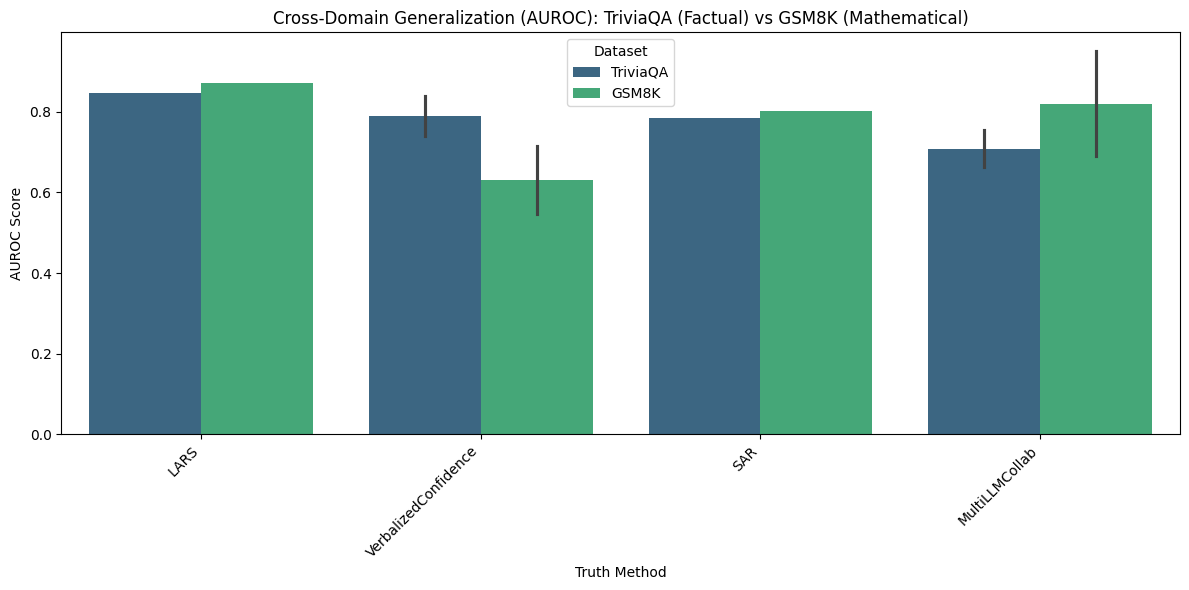

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_metrics(results_obj, dataset_name, model_name):
    rows = []
    for i in range(len(results_obj['eval_list'])):
        method = str(results_obj['output_dict']['truth_methods'][i])
        metrics = results_obj['eval_list'][i]
        row = {'Method': method, 'Dataset': dataset_name, 'Model': model_name}

        if isinstance(metrics, dict):
            row['auroc'] = float(metrics.get('auroc', 0))
            row['prr'] = float(metrics.get('prr', 0))
        else:
            row['auroc'] = float(metrics)

        rows.append(row)
    return pd.DataFrame(rows)

dfs = []
if 'results_1' in globals(): dfs.append(extract_metrics(results_1, 'TriviaQA', 'Llama-3-8B'))
if 'results_2' in globals(): dfs.append(extract_metrics(results_2, 'GSM8K', 'Llama-3-8B'))
if 'results_3' in globals(): dfs.append(extract_metrics(results_3, 'TriviaQA', 'GPT-4o-mini'))
if 'results_4' in globals(): dfs.append(extract_metrics(results_4, 'GSM8K', 'GPT-4o-mini'))

if len(dfs) > 0:
    combined_df = pd.concat(dfs, ignore_index=True)
    print("--- Combined Performance Metrics ---")
    display(combined_df)

    pivot_df = combined_df.pivot_table(index=['Model', 'Method'], columns='Dataset', values='auroc').reset_index()

    if 'TriviaQA' in pivot_df.columns and 'GSM8K' in pivot_df.columns:
        pivot_df['Degradation (TriviaQA - GSM8K)'] = pivot_df['TriviaQA'] - pivot_df['GSM8K']
        print("\n--- Cross-Domain Degradation Analysis (Sorted by largest drop) ---")
        display(pivot_df.sort_values('Degradation (TriviaQA - GSM8K)', ascending=False))

        plt.figure(figsize=(12, 6))
        sns.barplot(data=combined_df, x='Method', y='auroc', hue='Dataset', palette='viridis')
        plt.title('Cross-Domain Generalization (AUROC): TriviaQA (Factual) vs GSM8K (Mathematical)')
        plt.ylabel('AUROC Score')
        plt.xlabel('Truth Method')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Dataset')
        plt.tight_layout()
        plt.show()
    else:
        print("\nMissing results from both datasets")
else:
    print("No evaluation results found.")